**Import the libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Loading the Dataset

In [2]:
df = sns.load_dataset("mpg") #Miles per gallon dataset

In [3]:
df.head()# gives the first 5 rows of the dataset

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df.info() # gives the information about the dataset

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [5]:
df.drop(["name"], axis=1, inplace=True) # dropping the name column as it is not useful for our analysis

In [6]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


Summary of Data

In [7]:
df.describe() # gives the statistical summary of the dataset

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


Data Preprocessing

In [8]:
df.isnull().sum() # checking for missing values in the dataset

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)] # gives the rows with missing values

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
32,25.0,4,98.0,NaN,2046,19.0,71,usa
126,21.0,6,200.0,NaN,2875,17.0,74,usa
330,40.9,4,85.0,NaN,1835,17.3,80,europe
336,23.6,4,140.0,NaN,2905,14.3,80,usa
354,34.5,4,100.0,NaN,2320,15.8,81,europe
374,23.0,4,151.0,NaN,3035,20.5,82,usa


In [10]:
df.dropna(inplace=True) # drops the rows with missing values

In [11]:
df.isnull().sum().any() # checking for missing values in the dataset

np.False_

In [12]:
df.shape # gives the number of rows and columns in the dataset

(392, 8)

Univariate Analysis

In [13]:
df.cylinders.unique() # gives the unique values in the cylinders column

array([8, 4, 6, 3, 5])

In [14]:
df.cylinders.value_counts() # gives the count of each unique value in the cylinders column

cylinders
4    199
8    103
6     83
3      4
5      3
Name: count, dtype: int64

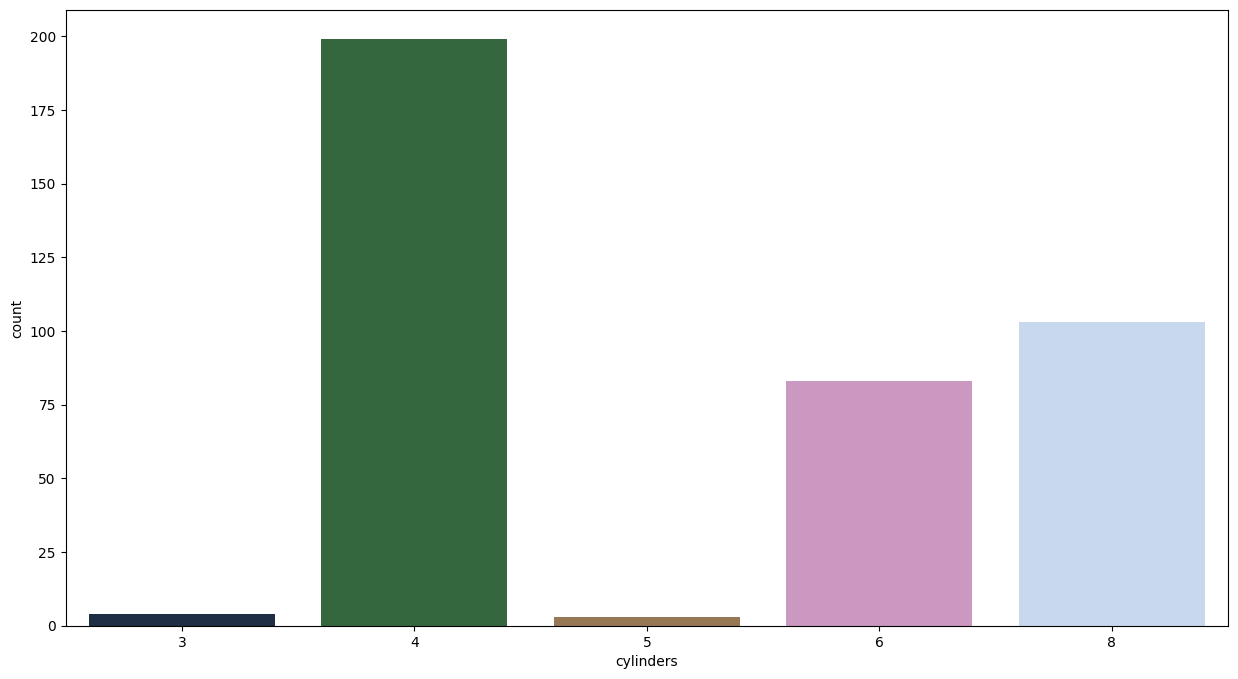

In [15]:
plt.figure(figsize=(15,8))
sns.countplot(data=df, x="cylinders", palette="cubehelix")
plt.show()

In [16]:
df["model_year"]= (1900 + df.model_year) # converting the model_year column to a more readable format

In [17]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,1970,usa
1,15.0,8,350.0,165.0,3693,11.5,1970,usa
2,18.0,8,318.0,150.0,3436,11.0,1970,usa
3,16.0,8,304.0,150.0,3433,12.0,1970,usa
4,17.0,8,302.0,140.0,3449,10.5,1970,usa


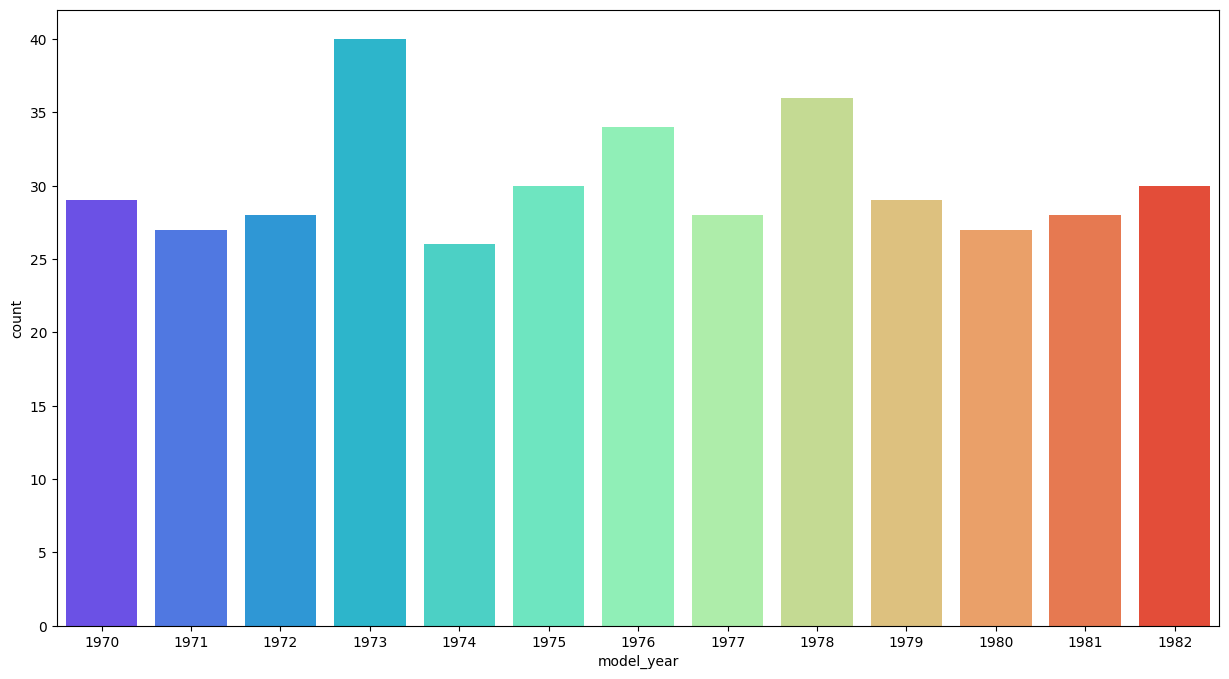

In [18]:
plt.figure(figsize=(15,8))
sns.countplot(data=df, x="model_year", palette="rainbow")
plt.show()

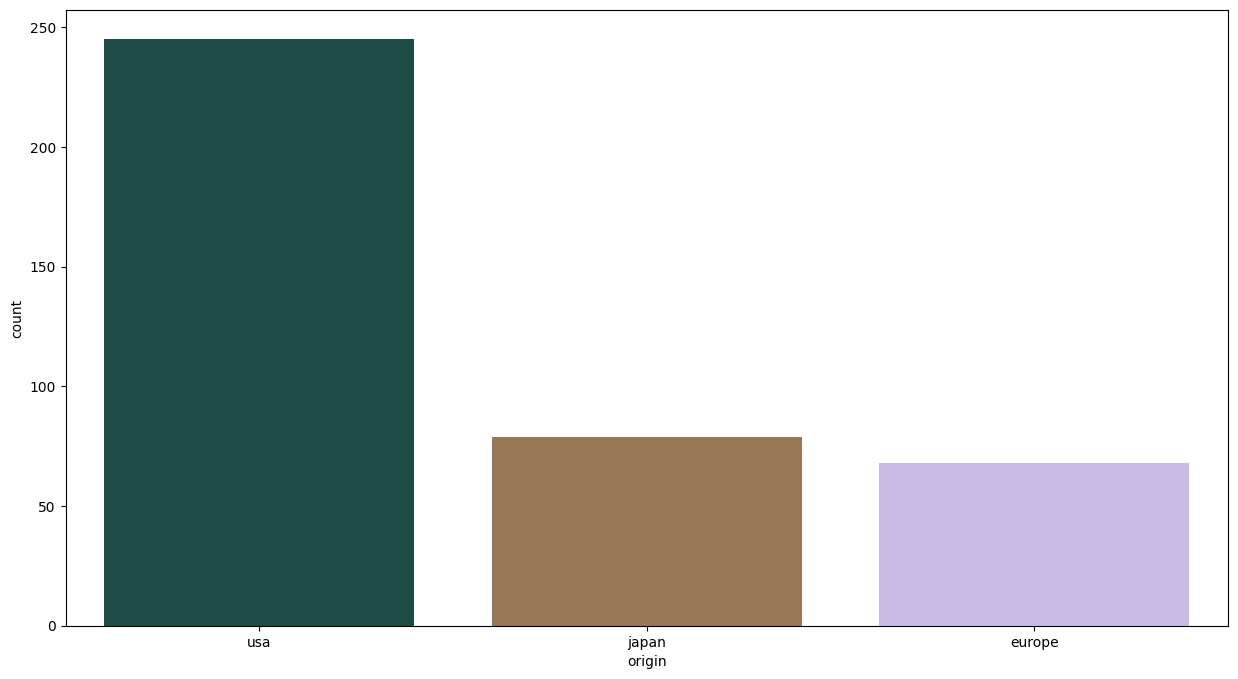

In [19]:
plt.figure(figsize=(15,8))
sns.countplot(data=df, x="origin", palette="cubehelix")
plt.show()

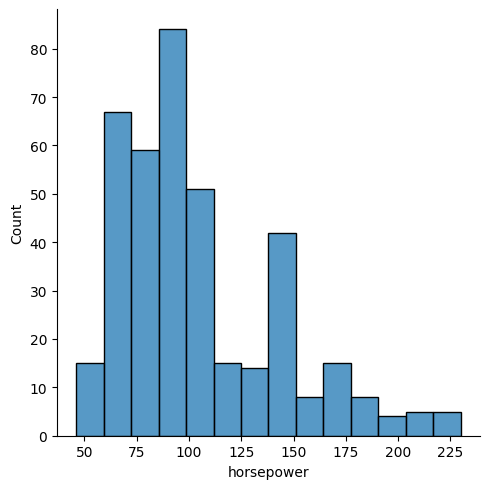

In [20]:
sns.displot(df["horsepower"])# gives the distribution of the horsepower column
plt.show()

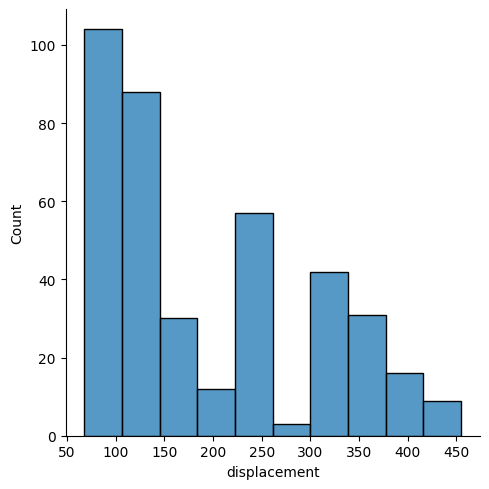

In [21]:
sns.displot(df["displacement"])# gives the distribution of the displacement column
plt.show()

Bivariate Analysis

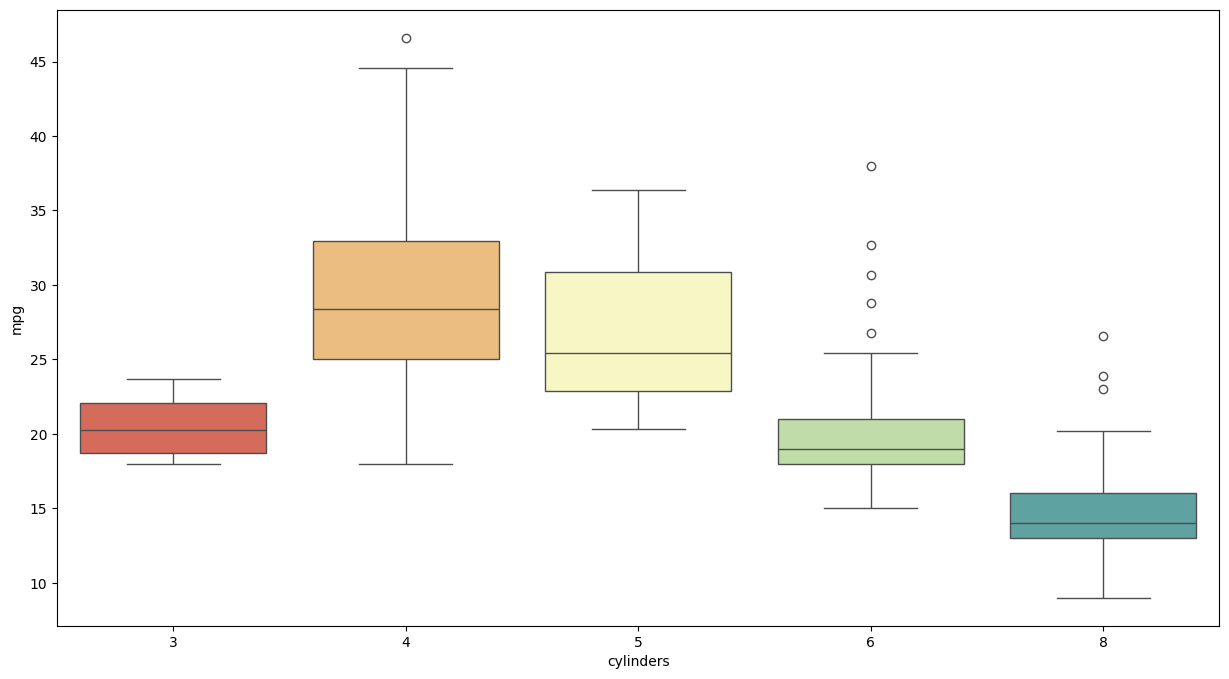

In [22]:
#target variable is miles per gallon(mpg) and the rest are the features. We will use the features to predict the target variable.
plt.figure(figsize=(15,8))
sns.boxplot(x= "cylinders", y="mpg", data=df, palette="Spectral") # gives the boxplot of the miles per gallon for each cylinder category
plt.show()

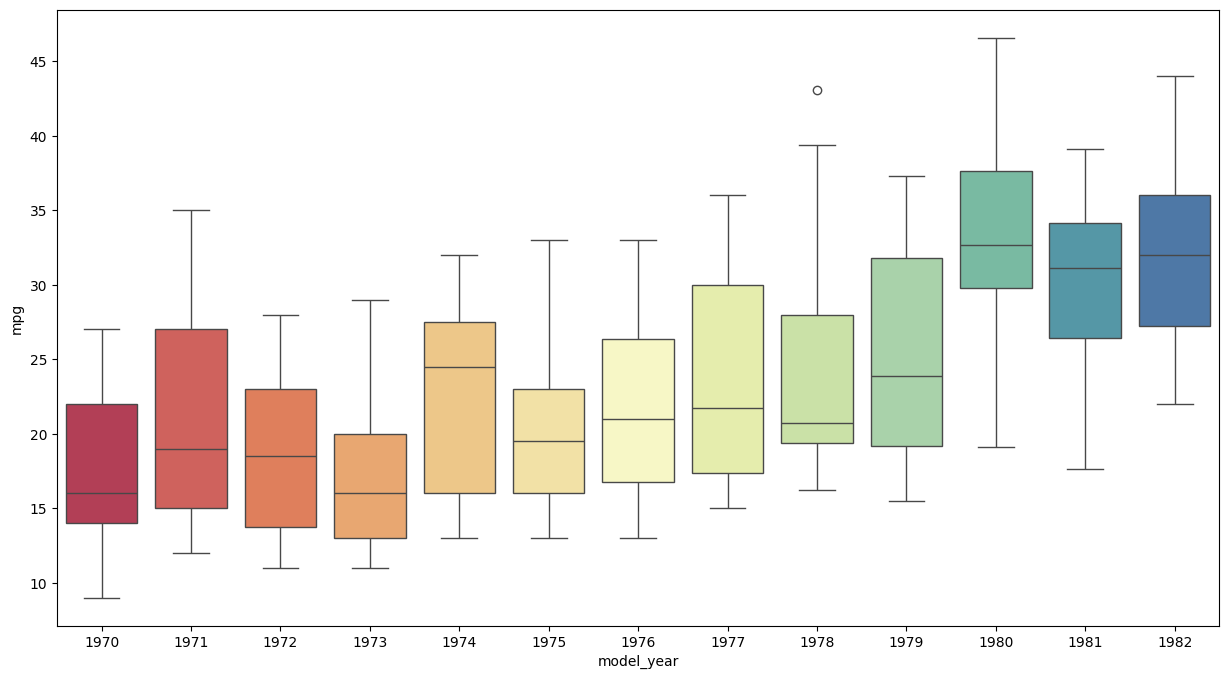

In [23]:
plt.figure(figsize=(15,8))
sns.boxplot(x= "model_year", y="mpg", data=df, palette="Spectral")
plt.show()

Multivariate Analysis

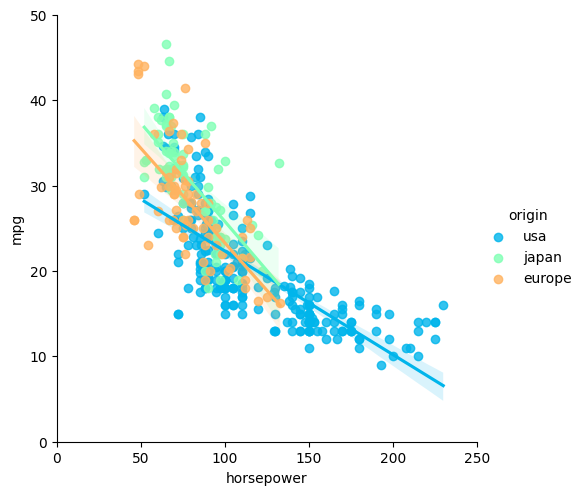

In [24]:
graph=sns.lmplot(x="horsepower", y="mpg", hue="origin", data=df , palette="rainbow") # gives the scatter plot of horsepower vs miles per gallon with different colors for different origins
graph.set(xlim=(0, 250), ylim=(0, 50)) # setting the limits for x and y axes
plt.show()

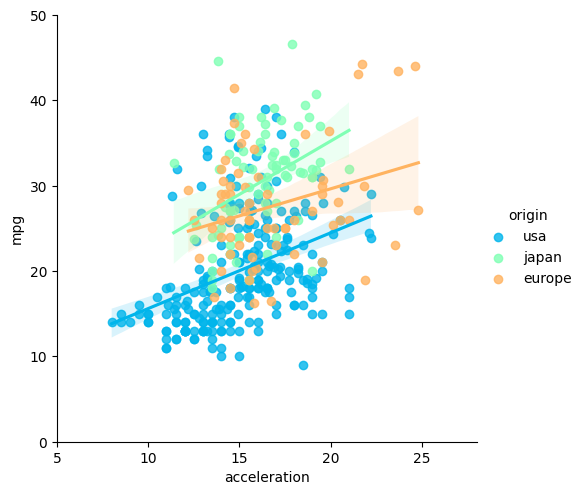

In [25]:
graph=sns.lmplot(x="acceleration", y="mpg", hue="origin", data=df , palette="rainbow") # gives the scatter plot of acceleration vs miles per gallon with different colors for different origins
graph.set(xlim=(5, 28), ylim=(0, 50)) # setting the limits for x and y axes
plt.show()

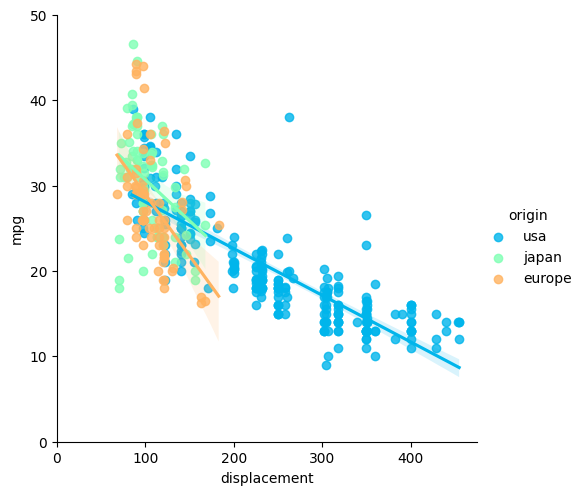

In [26]:
graph=sns.lmplot(x="displacement", y="mpg", hue="origin", data=df , palette="rainbow") # gives the scatter plot of displacement vs miles per gallon with different colors for different origins
graph.set(xlim=(0,475), ylim=(0, 50)) # setting the limits for x and y axes
plt.show()

Heatmap of the Correlation Matrix

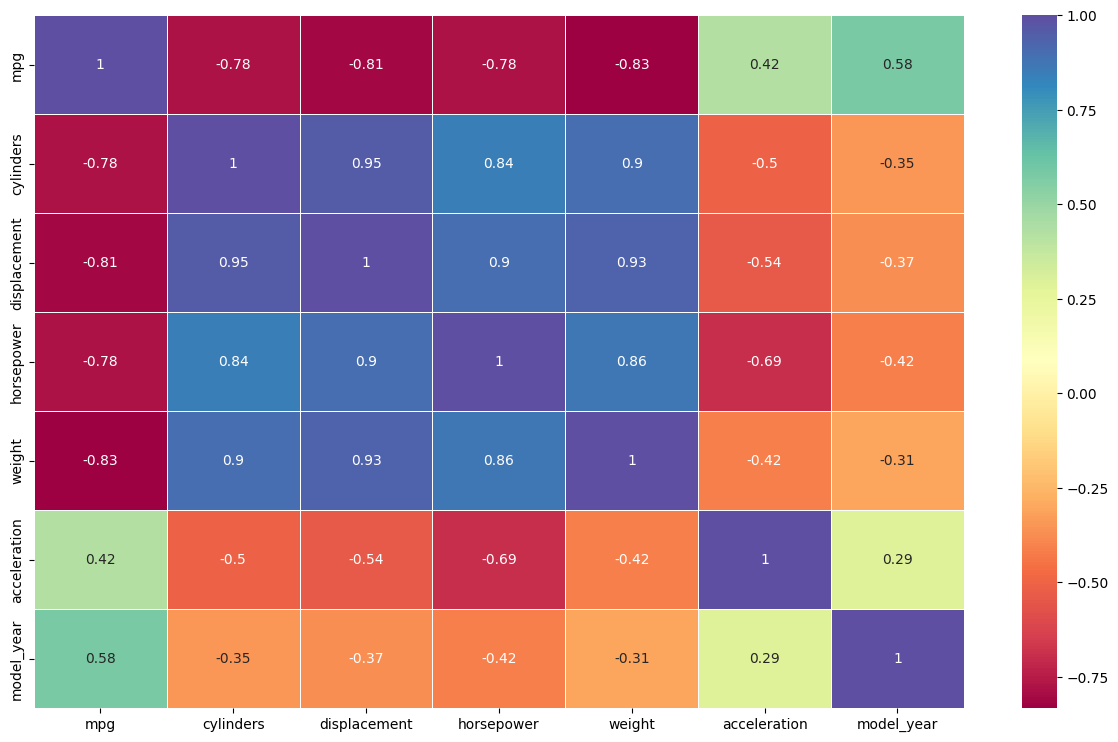

In [27]:
plt.figure(figsize=(15,9))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, linewidth=0.5, cmap="Spectral") # gives the heatmap of the correlation between the numerical features in the dataset
plt.show()

In [28]:
df.drop(["acceleration", "displacement"], axis=1, inplace=True) # dropping the acceleration and displacement columns as they are not useful for our analysis])

In [29]:
from datetime import datetime
today = datetime.today()

In [30]:
today

datetime.datetime(2026, 4, 13, 6, 10, 2, 292105)

In [31]:
this_year=today.year
df["age"]= this_year - df.model_year # creating a new column age which is the difference between the current year and the model year of the car

In [32]:
df.drop(["model_year"], axis=1, inplace=True) # dropping the model_year column as it is not useful for our analysis

In [33]:
df.head()

,mpg,cylinders,horsepower,weight,origin,age
0,18.0,8,130.0,3504,usa,56
1,15.0,8,165.0,3693,usa,56
2,18.0,8,150.0,3436,usa,56
3,16.0,8,150.0,3433,usa,56
4,17.0,8,140.0,3449,usa,56


In [34]:
df.origin.unique() # gives the unique values in the origin column

<StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str

In [35]:
df= pd.get_dummies(df, drop_first=True) # converting the origin column into dummy variables and dropping the first category to avoid multicollinearity

In [36]:
df.head()

,mpg,cylinders,horsepower,weight,age,origin_japan,origin_usa
0,18.0,8,130.0,3504,56,False,True
1,15.0,8,165.0,3693,56,False,True
2,18.0,8,150.0,3436,56,False,True
3,16.0,8,150.0,3433,56,False,True
4,17.0,8,140.0,3449,56,False,True


Modeling

In [37]:
X= df.drop("mpg", axis=1) # features
y= df["mpg"] # target variable

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # splitting the dataset into training and testing sets with 80% training and 20% testing data

In [39]:
X_train

,cylinders,horsepower,weight,age,origin_japan,origin_usa
260,6,110.0,3620,48,False,True
184,4,92.0,2572,50,False,True
174,6,97.0,2984,51,False,True
64,8,150.0,4135,54,False,True
344,4,64.0,1875,45,False,True
...,...,...,...,...,...,...
72,8,150.0,3892,54,False,True
107,6,100.0,2789,53,False,True
272,4,85.0,2855,48,False,True
352,4,65.0,2380,45,False,True


In [40]:
y_train

260    18.6
184    25.0
174    18.0
64     15.0
344    39.0
       ... 
72     15.0
107    18.0
272    23.8
352    29.9
103    11.0
Name: mpg, Length: 313, dtype: float64

Creating The Machine Learning Model

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
lm_model= LinearRegression() # creating an instance of the LinearRegression class

In [43]:
lm_model.fit(X_train, y_train) # fitting the linear regression model to the training data

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
lm_model.intercept_ # gives the intercept of the linear regression model

np.float64(81.36422963606496)

In [45]:
coef_param=pd.DataFrame(lm_model.coef_,index= X.columns, columns=["Coefficient"]) # creating a dataframe to store the coefficients of the linear regression model
coef_param

,Coefficient
cylinders,0.203056
horsepower,-0.014143
weight,-0.005729
age,-0.779904
origin_japan,0.401853
origin_usa,-2.385047


In [46]:
y_pred=lm_model.predict(X_test) # predicting the target variable for the testing data

In [47]:
my_dict={"Actual": y_test, "Predicted": y_pred} # creating a dictionary to store the actual and predicted values of the target variable
compare=pd.DataFrame(my_dict) # creating a dataframe from the dictionary to compare the actual and predicted values
compare.sample(10) # gives a random sample of 10 rows from the compare dataframe to see the actual and predicted values of the target variable

,Actual,Predicted
73,13.0,13.173142
389,22.0,28.056267
276,21.6,27.102313
31,25.0,25.575986
47,19.0,17.086203
43,13.0,8.115192
94,13.0,9.101600
78,21.0,21.764759
366,17.6,24.048994
385,38.0,35.885766


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [49]:
def evaluation_metrics(actual,pred):
    MAE= mean_absolute_error(actual, pred) # calculating the mean absolute error
    MSE= mean_squared_error(actual, pred) # calculating the mean squared error
    RMSE= np.sqrt(mean_squared_error(actual,pred)) # calculating the root mean squared error
    SCORE= r2_score(actual, pred) # calculating the R-squared score
    return print("r2 score:",SCORE,"\nMAE:",MAE,"\nMSE:",MSE,"\nRMSE:",RMSE) # printing the evaluation metrics

In [50]:
evaluation_metrics(y_test, y_pred) # evaluating the performance of the linear regression model using the evaluation metrics function

r2 score: 0.7798249880881916 
MAE: 2.5188281576150846 
MSE: 11.237861022823017 
RMSE: 3.3522919059686638


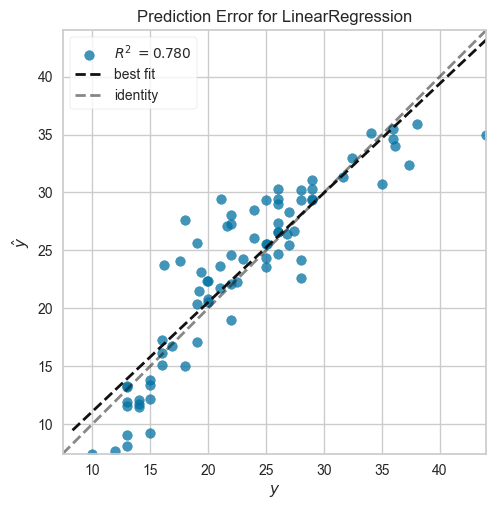

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [51]:
from yellowbrick.regressor import PredictionError

visualizer = PredictionError(lm_model, force_model=True) # force_model=True works around Yellowbrick mis-detecting this fitted LinearRegression model
visualizer.fit(X_train, y_train) # fitting the visualizer to the training data
visualizer.score(X_test, y_test) # scoring the visualizer on the testing data
visualizer.show() # showing the visualizer

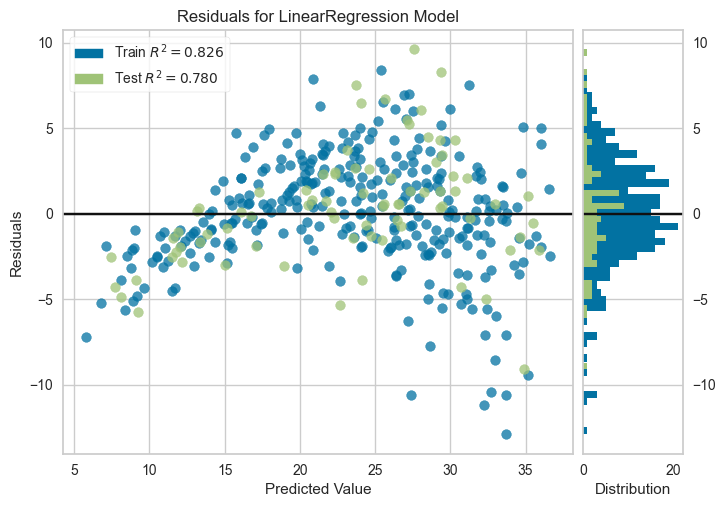

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [52]:
from yellowbrick.regressor import ResidualsPlot

visualizer = ResidualsPlot(lm_model, force_model=True) # force_model=True works around Yellowbrick mis-detecting this fitted LinearRegression model
visualizer.fit(X_train, y_train) # fitting the visualizer to the training data
visualizer.score(X_test, y_test) # scoring the visualizer on the testing data
visualizer.show() # showing the visualizer

K-folds Testing

In [53]:
from sklearn.model_selection import cross_val_score

In [54]:
accuracies = cross_val_score(estimator=lm_model, X=X_train, y=y_train, cv=10) # performing cross-validation on the training data with 5 folds

In [55]:
accuracies

array([0.83385985, 0.8017547 , 0.83571526, 0.79337835, 0.74392253,
       0.78022115, 0.85414984, 0.76313671, 0.81547906, 0.88691579])

In [56]:
accuracies.mean() # gives the mean accuracy of the cross-validation

np.float64(0.8108533245510495)

In [57]:
accuracies = cross_val_score(estimator=lm_model, X=X_train, y=y_train, cv=10 ,scoring="neg_mean_squared_error") # performing cross-validation on the training data with 5 folds and using negative mean squared error as the scoring metric

In [59]:
-accuracies.mean() # gives the mean accuracy of the cross-validation

np.float64(11.79038791944338)